## Black Scholes Option Pricing

✅ Standard Normal Distribution <br>
✅ Black Scholes Call Option Explanation <br>
✅ Black Scholes Put Option.  Put Call Parity <br>
✅ Greeks <br>
✅ Newton Rhapson General <br>
✅ Newton Rhapson for Black Scholes Solving For Implied Volatility <br>
✅ Traders Use of Implied Volatility

#### Standard Normal Review



$$
\phi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}
$$

$$
\Phi(x) = \int_{-\infty}^{x} \phi(t)\,dt
$$

$$
\frac{d}{dx}\Phi(x) = \phi(x)
$$

**Parameters**
- $x$: real number (argument of the distribution).  
- $\phi(x)$: standard normal probability density function (PDF).  
- $\Phi(x)$: standard normal cumulative distribution function (CDF).  


##### Graph of PDF and CDF

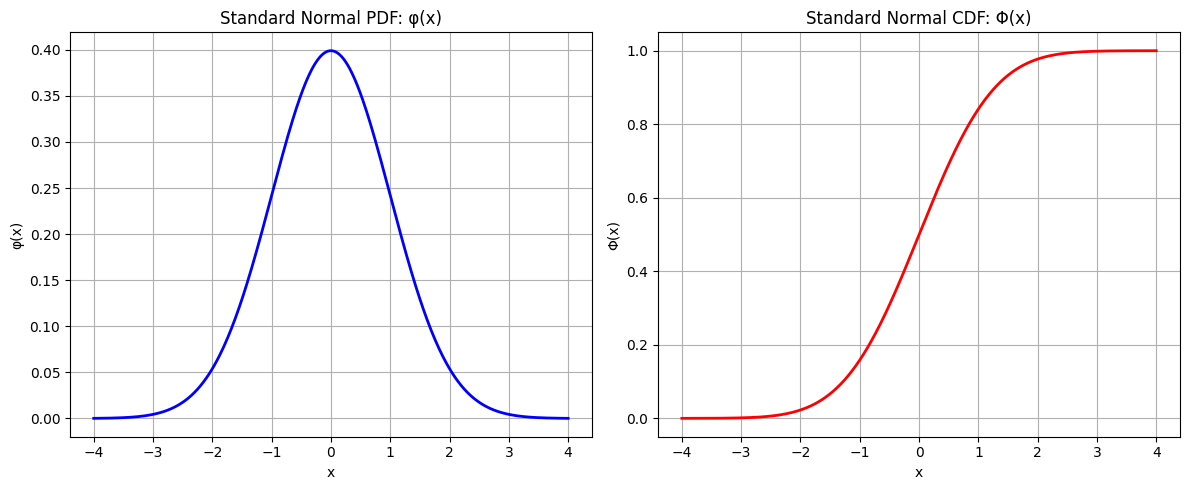

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define range of x values
x = np.linspace(-4, 4, 500)

# PDF and CDF values
pdf = norm.pdf(x)
cdf = norm.cdf(x)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- PDF ---
axes[0].plot(x, pdf, 'b-', linewidth=2)
axes[0].set_title("Standard Normal PDF: φ(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("φ(x)")
axes[0].grid(True)

# --- CDF ---
axes[1].plot(x, cdf, 'r-', linewidth=2)
axes[1].set_title("Standard Normal CDF: Φ(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Φ(x)")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Black Sholes Call Option Explanation



$$
C(S,K,T,r,\sigma) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)
$$

with

$$
d_1 = \frac{\ln\!\left(\dfrac{S}{K}\right) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}.
$$

**Parameters**
- $C$: call option price (output, currency units).  
- $S$: current underlying (spot) price (same currency as $K$).  
- $K$: strike price (same currency as $S$).  
- $T$: time to maturity, in **years** (e.g. 0.5 = 6 months).  
- $r$: continuously compounded risk-free rate (annual, decimal; e.g. 0.05 = 5%).  
- $\sigma$: volatility (annualized, decimal; e.g. 0.20 = 20%).  
- $\Phi$: standard normal CDF, $\phi$: standard normal PDF.  
- Note: ensure $T>0$ and $\sigma>0$ for $d_1,d_2$ formulas to be valid.


#### Black Scholes European Put Price (Put Call Parity)



$$
P(S,K,T,r,\sigma) = K e^{-rT}\,\Phi(-d_2) - S\,\Phi(-d_1)
$$

where $d_1,d_2$ are the same as in the call formula.

**Put–Call Parity**

$$
C - P = S - K e^{-rT}
$$

**Parameters**
- $P$: put option price (output, currency units).  
- Other parameters: same meanings as in the call cell ($S,K,T,r,\sigma$).  
- Put–Call parity holds for European options under Black–Scholes assumptions.


### Greeks

The Greeks are a set of risk measures, or sensitivities, derived from the Black-Scholes model that quantify how the option's price changes in response to changes in the model's inputs.

#### Vega (ν) – Sensitivity to Volatility

**Definition:** Vega measures how much the option price changes for a 1% change in implied volatility.

**Formula:**
$$
\mathrm{Vega}(S,K,T,r,\sigma) = \frac{\partial C_{BS}}{\partial\sigma} = S \sqrt{T}\,\phi(d_1)
$$

**Parameters**
- $\mathrm{Vega}$: change in option price per unit change in $\sigma$ (units = currency per 1.0 of $\sigma$).  
  - If you express $\sigma$ in decimals, Vega is per 1.0 (i.e., per 100 percentage points). For per 1% change use $\mathrm{Vega}/100$.  
- $S,K,T,r,\sigma$: same as previous cells.  
- $\phi(d_1)$: standard normal PDF evaluated at $d_1$.


#### Delta (Δ) – Sensitivity to Stock Price



**Definition:** Delta measures how much the option price changes for a $1 change in the underlying stock.

**Formula (Call Option):**

$$\Delta = N(d_1)$$

**Where:**  
- $N(d_1)$ = cumulative standard normal at $d_1$  
- $d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$

**Intuition:**  
- Δ = 0.6 → if stock goes up $1, the call price increases ~$0.60.


#### Gamma (Γ) – Sensitivity of Delta to Stock Price

**Definition:** Gamma measures how much Delta changes for a $1 change in the underlying stock.

**Formula:**

$$\Gamma = \frac{N'(d_1)}{S \sigma \sqrt{T}}$$

**Where:**  
- $N'(d_1)$ = standard normal PDF at $d_1$  
- $S$ = stock price, $\sigma$ = volatility, $T$ = time to expiration

**Intuition:**  
- High Gamma → Delta changes rapidly; option price accelerates faster as stock moves.

#### Theta (Θ) – Sensitivity to Time

**Definition:** Theta measures how much the option price decreases as time passes (time decay).

**Formula (Call Option):**

$$\Theta = -\frac{S N'(d_1) \sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2)$$

**Where:**  
- $r$ = risk-free rate  
- $K$ = strike price  
- $N(d_2)$ = cumulative standard normal at $d_2$  
- $d_2 = d_1 - \sigma \sqrt{T}$

**Intuition:**  
- Theta is usually negative; long calls lose value as expiration approaches.

### Newton Rhapson General

The Newton-Raphson method is a root-finding algorithm that uses an initial guess to find successively better approximations of the root of a real-valued function by repeatedly calculating the point where the tangent line to the function at the previous guess intersects the x-axis.


$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

**Parameters / algorithm inputs**
- $f(x)$: the function whose root we want ($f(x^*) = 0$).  
- $f'(x)$: derivative of $f$ with respect to $x$.  
- $x_0$: initial guess for $x$ (user-specified).  
- $\text{tol}$: convergence tolerance (stop when $|f(x_n)| < \text{tol}$ or $|x_{n+1}-x_n| < \text{tol}$).  
- $\text{max\_iter}$: maximum number of iterations.  
- Practical warning: if $f'(x_n)\approx 0$ the step can blow up — use fallback (bisection/Brent) or guard against tiny denominators.


##### Newton Rhapson Python Example

In [ ]:
# Newton-Raphson method example

# Function and its derivative
def f(x):
    return x**2 - 2

def f_prime(x):
    return 2*x

# Initial guess
x0 = 1.0
tolerance = 1e-6
max_iterations = 10

x = x0
for i in range(max_iterations):
    x_new = x - f(x)/f_prime(x)
    print(f"Iteration {i+1}: x = {x_new}")

    if abs(x_new - x) < tolerance:
        print("Converged!")
        break

    x = x_new

print(f"Estimated root: {x}")


Iteration 1: x = 1.5
Iteration 2: x = 1.4166666666666667
Iteration 3: x = 1.4142156862745099
Iteration 4: x = 1.4142135623746899
Iteration 5: x = 1.4142135623730951
Converged!
Estimated root: 1.4142135623746899


### Newton-Rhapson for Black-Scholes Implied Volatility


Define the root-finding function:

$$
f(\sigma) = C_{BS}(S,K,T,r,\sigma) - C_{\text{market}}
$$

where $C_{BS}$ is the Black–Scholes call price.

Derivative:

$$
f'(\sigma) = \frac{\partial C_{BS}}{\partial\sigma} = \mathrm{Vega}(S,K,T,r,\sigma).
$$

Newton update:

$$
\sigma_{n+1} = \sigma_n - \frac{C_{BS}(S,K,T,r,\sigma_n) - C_{\text{market}}}{\mathrm{Vega}(S,K,T,r,\sigma_n)}
$$

**Parameters / algorithm inputs (explicit)**
- $C_{\text{market}}$: observed market price of the option (currency).  
- $S,K,T,r$: same as in Black–Scholes cells.  
- $\sigma$: implied volatility to solve for (annualized, decimal).  
- $\sigma_0$: initial guess (e.g. $0.20$).  
- $\text{tol_price}$: price tolerance, stop when $|C_{BS}(\sigma_n)-C_{\text{market}}| < \text{tol_price}$ (e.g. $1\times 10^{-8}$).  
- $\text{tol_sigma}$: small-change tolerance for $\sigma$ (e.g. $1\times 10^{-12}$).  
- $\text{max_iter}$: maximum iterations (e.g. $100$).  
- $\text{vega_threshold}$: if $\mathrm{Vega}(\sigma_n) < \text{vega_threshold}$ then NR is unreliable; use fallback (e.g. bisection). A typical tiny threshold: $1\times 10^{-8}$.  
- Practical safeguards: clamp $\sigma_{n+1}$ to remain positive (e.g. $\sigma_{n+1}=\max(\sigma_{n+1}, 1\times 10^{-12})$) and to a reasonable upper bound (e.g. $5.0$) if needed.


##### Solving For Implied Volatility using Black Scholes and Newton Rhapson

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

# -------------------------
# Black-Scholes price and Vega
# -------------------------
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        # degenerate: option value = max(S-K*e^{-rT}, 0) for T ~ 0 (approx)
        return max(S - K * math.exp(-r * T), 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put_price(S, K, T, r, sigma):
    # or use put-call parity
    if sigma <= 0 or T <= 0:
        return max(K * math.exp(-r * T) - S, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def vega(S, K, T, r, sigma):
    # Vega = S * sqrt(T) * phi(d1)
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * np.sqrt(T) * norm.pdf(d1)

# -------------------------
# 3) Newton-Raphson implied vol solver (with iteration printout)
# -------------------------
def implied_vol_newton(C_market, S, K, T, r,
                       sigma0=0.2, tol_price=1e-8, tol_sigma=1e-12,
                       max_iter=100, verbose=True):
    sigma = float(sigma0)
    if sigma <= 0:
        sigma = 1e-4
    header = f"{'iter':>4} | {'sigma':>10} | {'price':>11} | {'diff':>11} | {'vega':>11}"
    if verbose:
        print(header)
        print("-" * len(header))
    for i in range(max_iter):
        price = bs_call_price(S, K, T, r, sigma)
        diff = price - C_market
        v = vega(S, K, T, r, sigma)
        if verbose:
            print(f"{i:4d} | {sigma:10.8f} | {price:11.8f} | {diff:11.8f} | {v:11.8f}")
        # Stopping conditions
        if abs(diff) < tol_price or abs(v) < 1e-16:
            # either matched price or vega too small (can't trust NR)
            if verbose:
                if abs(diff) < tol_price:
                    print("Converged: price difference within tolerance.")
                else:
                    print("Stopping: vega too small (NR unreliable).")
            return max(sigma, 1e-12)
        # Newton step
        step = diff / v
        sigma_new = sigma - step
        # Guard against negative or extreme sigma
        if sigma_new <= 0 or sigma_new > 10:
            # fallback: simple clamp or small step toward a reasonable range
            sigma_new = max(1e-12, min(max(sigma * 0.5, sigma_new), 5.0))
        if abs(sigma_new - sigma) < tol_sigma:
            sigma = sigma_new
            if verbose:
                print("Converged: sigma change within tolerance.")
            return max(sigma, 1e-12)
        sigma = sigma_new
    if verbose:
        print("Warning: did not converge within max_iter.")
    return max(sigma, 1e-12)

# -------------------------
# Example usage
# -------------------------
S = 100.0
K = 100.0
T = 1.0
r = 0.05

# Suppose market call price is:
C_market = 10.0

implied_vol = implied_vol_newton(C_market, S, K, T, r, sigma0=0.2, verbose=True)
print("\nImplied volatility:", implied_vol)


iter |      sigma |       price |        diff |        vega
-----------------------------------------------------------
   0 | 0.20000000 | 10.45058357 |  0.45058357 | 37.52403469
   1 | 0.18799213 | 10.00076595 |  0.00076595 | 37.39153647
   2 | 0.18797165 | 10.00000000 |  0.00000000 | 37.39128420
Converged: price difference within tolerance.

Implied volatility: 0.187971649526008


### Traders Outlook

Here’s what they use Implied Vol for:

1. **Comparing options fairly**

The actual option price you see in the market is driven by supply/demand.

By backing out IV, traders can compare different options (different strikes, maturities, or even different stocks) on a common scale of expected volatility.

2. **Judging whether options are cheap or expensive**

If current IV is high relative to past/historical volatility, options may be expensive → traders might sell options (collect premium).

If current IV is low, options may be cheap → traders might buy options.

3. **Risk management and hedging**

Many strategies (like straddles, strangles, spreads) are basically bets on volatility itself.

Knowing IV helps traders decide which structure fits their market view.

4. **Market sentiment gauge**

IV reflects the market’s fear or uncertainty.

Example: the VIX index (often called the “fear index”) is just a measure of implied volatility on S&P 500 options.